<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Dimension005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

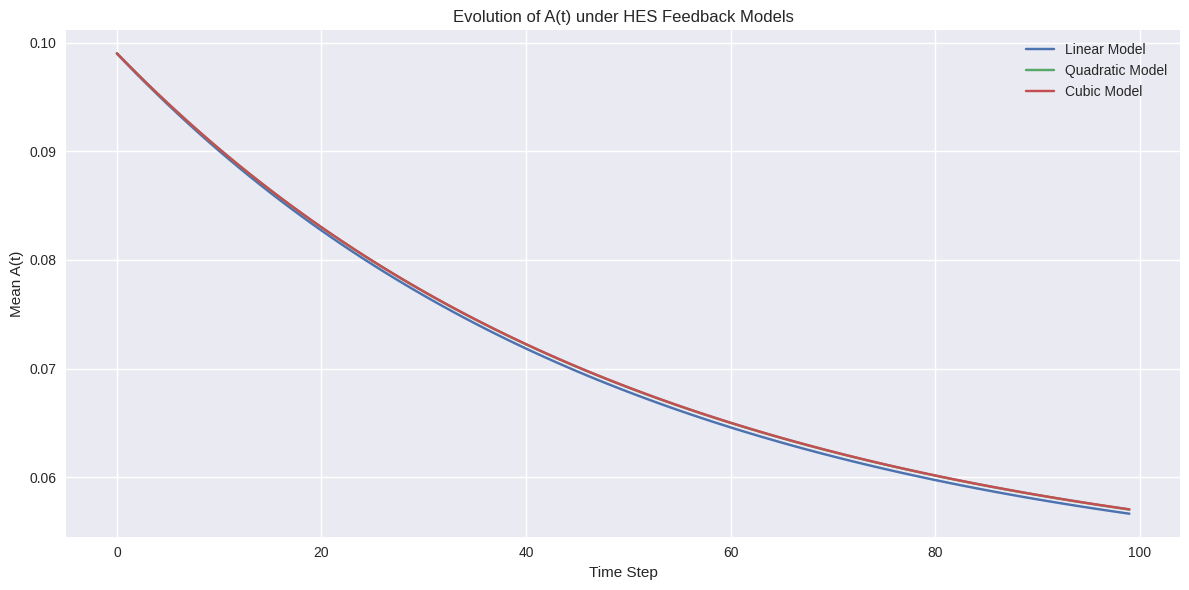

In [3]:
# Simulating nonlinear HES evolution with cubic feedback term to refine neutrino mixing angle θ₁₃

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Parameters
# -------------------------------
epsilon = 0.01     # Cubic feedback strength
kappa = 0.2        # Linear damping
delta = 0.02       # Quadratic feedback
gamma0 = 0.5       # Spatial coupling
xi = 0.01          # Noise amplitude
A0 = 0.1           # Initial condition
time_steps = 100   # Number of frames
grid_size = 50     # Spatial resolution

# -------------------------------
# Evolution Function
# -------------------------------
def evolve_model(model='cubic'):
    A = np.ones(grid_size) * A0
    history = []

    for t in range(time_steps):
        laplacian = np.roll(A, -1) - 2 * A + np.roll(A, 1)
        noise = xi

        if model == 'linear':
            dA_dt = -kappa * A + gamma0 * laplacian + noise
        elif model == 'quadratic':
            dA_dt = -kappa * A + delta * A**2 + gamma0 * laplacian + noise
        elif model == 'cubic':
            dA_dt = -kappa * A + delta * A**2 + epsilon * A**3 + gamma0 * laplacian + noise

        A += dA_dt * 0.1
        history.append(np.mean(A))

    return history

# -------------------------------
# Run All Models
# -------------------------------
models = ['linear', 'quadratic', 'cubic']
results = {m: evolve_model(m) for m in models}

# -------------------------------
# Plot Results
# -------------------------------
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(12, 6))
for m in models:
    plt.plot(results[m], label=f'{m.capitalize()} Model')
plt.title("Evolution of A(t) under HES Feedback Models")
plt.xlabel("Time Step")
plt.ylabel("Mean A(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
